In [1]:
from langgraph.graph import StateGraph,START,END
from  langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

d:\GenerativeAI\LangGraph_Learning\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [2]:
model=ChatMistralAI(
    model_name="mistral-small-latest"
)

In [5]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str


In [6]:
def create_outline(state:BlogState)->BlogState:
    #fetch title
    title=state['title']

    #call the llm gen outline
    prompt=f"Generate an outline for a blog on the topic {title}"

    outline=model.invoke(prompt)


    #update state
    outline=state['outline']

    return state

In [7]:
def create_blog(state:BlogState)->BlogState:
    
    title=state['title']
    outline=state['outline']

    prompt=f"wrtie the detail blog for the given title {title} using the given outline \n {outline}"

    content=model.invoke(prompt).content

    state['content']=content

    return state




In [8]:
graph=StateGraph(BlogState)

graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)


graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)




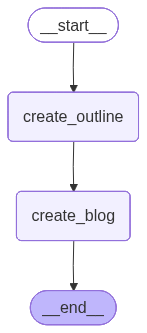

In [9]:
from IPython.display import Image

#compile the graph
workflow=graph.compile()
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
#execute the graph

initial_state={'title':"rise of ai in india"}
final_state=workflow.invoke(initial_state)

print(final_state)


KeyError: 'outline'